In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

In [4]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# Cargar datos
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Eliminar columnas innecesarias
df.drop("customerID", axis=1, inplace=True)

# Convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Eliminar filas con valores faltantes
df.dropna(inplace=True)

# Convertir la variable objetivo SOLO UNA VEZ
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

# Variables predictoras
X = df.drop("Churn", axis=1)

# Convertir variables categóricas
X = pd.get_dummies(X, drop_first=True)

# Convertir booleanos a enteros
X = X.astype(int)

# Variable objetivo
y = df["Churn"].astype(int)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
predicciones = modelo.predict(X_test)

In [17]:
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.61      0.44      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



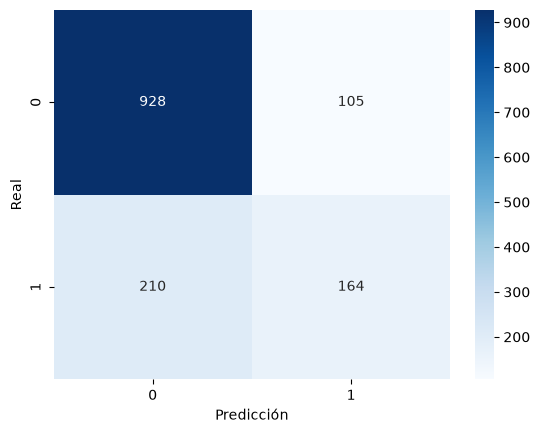

In [18]:
sns.heatmap(confusion_matrix(y_test, predicciones),
            annot=True,
            fmt='d',
            cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

La matriz de confusión muestra que el modelo obtuvo una exactitud aproximada del 77.6 %, clasificando correctamente 1092 de 1407 clientes. El modelo identifica de manera efectiva a los clientes que permanecen en la empresa (928 verdaderos negativos), pero presenta dificultades para detectar a quienes cancelan el servicio, ya que 210 clientes fueron clasificados erróneamente como clientes que permanecerían. Esto indica que, aunque el modelo es útil como herramienta predictiva, podría mejorarse para incrementar la detección de clientes con riesgo de abandono mediante técnicas como el ajuste de hiperparámetros, el balanceo de clases (por ejemplo, con SMOTE) o el uso de algoritmos más robustos como XGBoost o LightGBM.

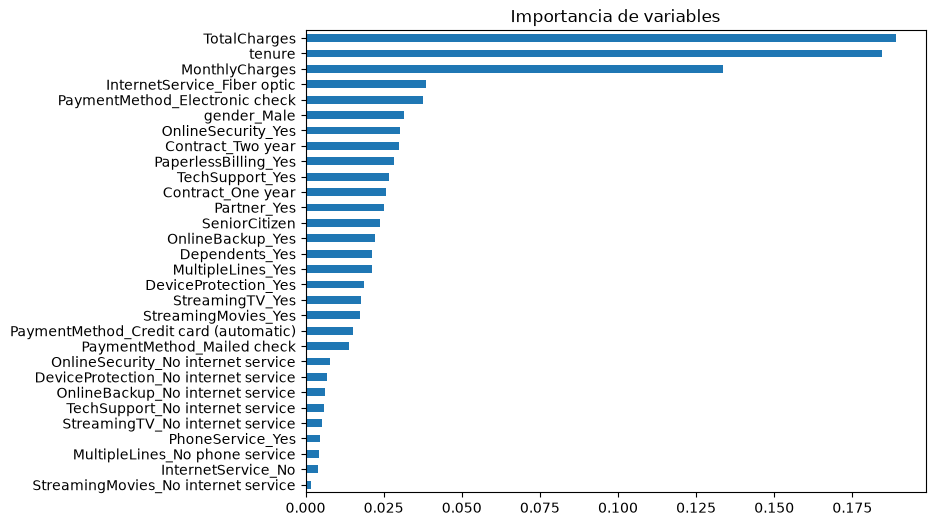

In [19]:
importancias = pd.Series(modelo.feature_importances_,
                         index=X.columns)

importancias.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Importancia de variables")
plt.show()

La gráfica de importancia de variables obtenida mediante el algoritmo Random Forest muestra que TotalCharges, tenure y MonthlyCharges son las variables que más influyen en la predicción de la cancelación del servicio. Esto indica que los factores económicos y el tiempo de permanencia del cliente son los principales determinantes del abandono. En contraste, variables relacionadas con servicios adicionales, como películas en streaming o la ausencia de servicio de internet, presentan una contribución mínima al modelo, por lo que su impacto en la predicción es reducido.

El modelo alcanzó una exactitud del 77.6 % y basó principalmente sus predicciones en el monto total pagado por el cliente, su antigüedad y los cargos mensuales. Esto sugiere que las características económicas y la permanencia del cliente son los factores más relevantes para anticipar la cancelación del servicio.